# Titanic Dataset — Complete Analysis
## Columns:
- PassengerId: Unique ID
- Age: Passenger ki age
- Fare: Ticket price
- Sex: 0=Male, 1=Female
- SibSp: Siblings/Spouse aboard
- Parch: Parents/Children aboard
- Pclass: Ticket class (1=First, 2=Second, 3=Third)
- Embarked: Port (0=Cherbourg, 1=Queenstown, 2=Southampton)
- Survived: 0=Died, 1=Survived (TARGET VARIABLE)

#Cell 2 — File Load + Basic Info

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [6]:
df = pd.read_csv('titanic.csv')

In [7]:
df.shape

(1309, 9)

In [8]:
df.columns.tolist()

['Passengerid',
 'Age',
 'Fare',
 'Sex',
 'sibsp',
 'Parch',
 'Pclass',
 'Embarked',
 'Survived']

In [9]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [10]:
df.tail()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
1304,1305,28.0,8.0500,0,0,0,3,2.0,0
1305,1306,39.0,108.9000,1,0,0,1,0.0,0
1306,1307,38.5,7.2500,0,0,0,3,2.0,0
1307,1308,28.0,8.0500,0,0,0,3,2.0,0
1308,1309,28.0,22.3583,0,1,1,3,0.0,0


In [11]:
df.dtypes

Passengerid      int64
Age            float64
Fare           float64
Sex              int64
sibsp            int64
Parch            int64
Pclass           int64
Embarked       float64
Survived         int64
dtype: object

In [12]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.493506,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814244,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


#Cell 3 — File Handling Operations

In [13]:
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
Survived       0
dtype: int64

In [14]:
print("Missing % per column:")
print((df.isnull().sum() / len(df) * 100).round(2))
print()

Missing % per column:
Passengerid    0.0
Age            0.0
Fare           0.0
Sex            0.0
sibsp          0.0
Parch          0.0
Pclass         0.0
Embarked       0.0
Survived       0.0
dtype: float64



In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\joysh\AppData\Local\Temp\ipykernel_16800\2359842934.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\joysh\AppData\Local\Temp\ipykernel_16800\2359842934.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

0       2.0
1       0.0
2       2.0
3       2.0
4       2.0
       ... 
1304    2.0
1305    0.0
1306    2.0
1307    2.0
1308    0.0
Name: Embarked, Length: 1309, dtype: float64

In [17]:
df[['Age','Survived']].head()

,Age,Survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


In [18]:
# 2.5 Filter rows
print("=== FILTERING ===")
survivors = df[df['Survived'] == 1]
print("Total Survivors:", len(survivors))


=== FILTERING ===
Total Survivors: 342


In [19]:
len(df[df['Pclass']==1])

323

In [20]:
first_class = df[df['Pclass'] == 1]
print("First Class passengers:", len(first_class))

First Class passengers: 323


In [21]:
young_survivors = df[(df['Age'] < 18) & (df['Survived'] == 1)]
print("Child survivors (age < 18):", len(young_survivors))
total = df[(df['Age'] < 18) ]
print("total child passenngers:",len(total))
print()


Child survivors (age < 18): 61
total child passenngers: 154



In [22]:
print("=== VALUE COUNTS ===")
print("Survival count:")
print(df['Survived'].value_counts())
print()

=== VALUE COUNTS ===
Survival count:
Survived
0    967
1    342
Name: count, dtype: int64



In [23]:
df['Pclass'].value_counts()

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [24]:
print("=== GROUPBY ===")
print("Survival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean().round(2))
print()

=== GROUPBY ===
Survival rate by Pclass:
Pclass
1    0.42
2    0.31
3    0.17
Name: Survived, dtype: float64



In [25]:
print("Average Fare by Class:")
print(df.groupby('Pclass')['Fare'].mean().round(2))
print()

Average Fare by Class:
Pclass
1    87.51
2    21.18
3    13.30
Name: Fare, dtype: float64



In [26]:
# 2.9 New column add karo
df['FamilySize'] = df['sibsp'] + df['Parch'] + 1
print("Family Size column added:")
print(df[['sibsp', 'Parch', 'FamilySize']].head())
print()

Family Size column added:
   sibsp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1



#Cell 4 — Univariate Analysis

In [27]:
# 3.1 Age analysis
print("--- Age Statistics ---")
print("Mean Age:", df['Age'].mean().round(2))
print("Median Age:", df['Age'].median())
print("Mode Age:", df['Age'].mode()[0])
print("Min Age:", df['Age'].min())
print("Max Age:", df['Age'].max())
print("Std Dev:", df['Age'].std().round(2))
print("Skewness:", df['Age'].skew().round(2))
print("Kurtosis:", df['Age'].kurtosis().round(2))
print()

--- Age Statistics ---
Mean Age: 29.5
Median Age: 28.0
Mode Age: 28.0
Min Age: 0.17
Max Age: 80.0
Std Dev: 12.91
Skewness: 0.54
Kurtosis: 0.97



In [28]:
print("--- Fare Statistics ---")
print(df['Fare'].describe())
print()


--- Fare Statistics ---
count    1309.000000
mean       33.281086
std        51.741500
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: Fare, dtype: float64



In [29]:
print("--- Survived (Categorical) ---")
print(df['Survived'].value_counts())
print()
print("Survival Rate:", (df['Survived'].mean() * 100).round(2), "%")

--- Survived (Categorical) ---
Survived
0    967
1    342
Name: count, dtype: int64

Survival Rate: 26.13 %


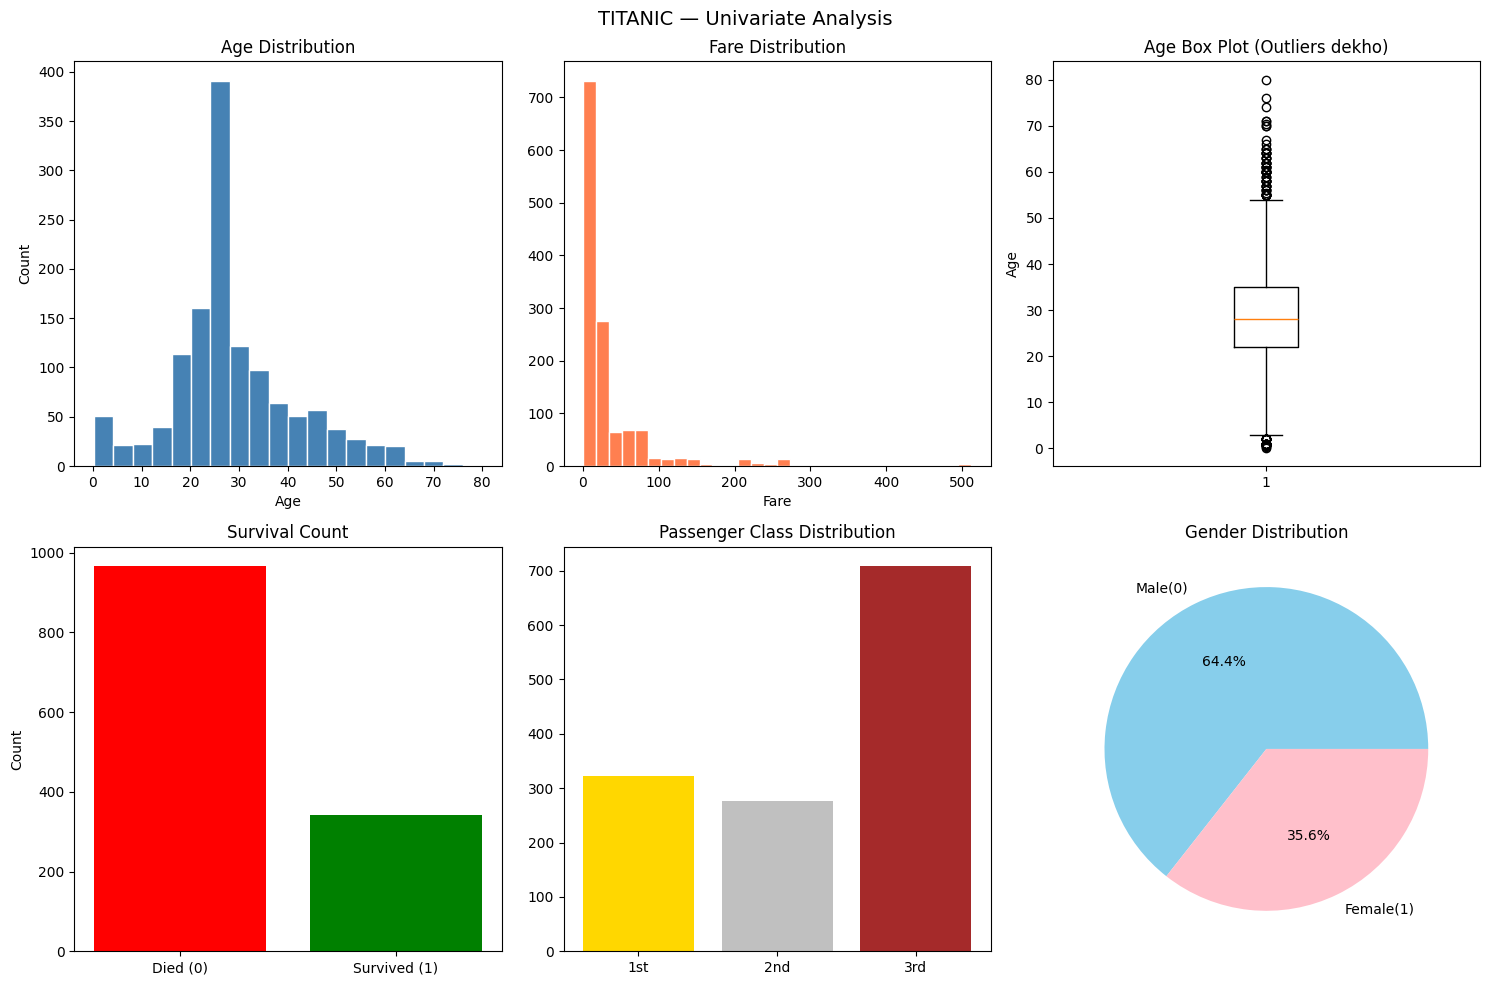

In [31]:
# ============================================
# STEP 3 — UNIVARIATE ANALYSIS
# Ek column ka ek time pe analysis
# ============================================

import matplotlib.pyplot as plt
# ---- Plots ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histogram — Age
axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Histogram — Fare
axes[0,1].hist(df['Fare'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Fare Distribution')
axes[0,1].set_xlabel('Fare')

# Box Plot — Age
axes[0,2].boxplot(df['Age'])
axes[0,2].set_title('Age Box Plot (Outliers dekho)')
axes[0,2].set_ylabel('Age')

# Bar Chart — Survived
survived_counts = df['Survived'].value_counts()
axes[1,0].bar(['Died (0)', 'Survived (1)'], survived_counts.values,
               color=['red', 'green'])
axes[1,0].set_title('Survival Count')
axes[1,0].set_ylabel('Count')

# Bar Chart — Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[1,1].bar(['1st', '2nd', '3rd'], pclass_counts.values,
               color=['gold', 'silver', 'brown'])
axes[1,1].set_title('Passenger Class Distribution')

# Pie Chart — Sex
sex_counts = df['Sex'].value_counts()
axes[1,2].pie(sex_counts.values, labels=['Male(0)', 'Female(1)'],
               autopct='%1.1f%%', colors=['skyblue', 'pink'])
axes[1,2].set_title('Gender Distribution')

plt.suptitle('TITANIC — Univariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

#Cell 5 — Bivariate Analysis

In [33]:
print(df.groupby('Survived')['Age'].mean().round(2))

Survived
0    29.93
1    28.29
Name: Age, dtype: float64


In [37]:
print((df.groupby('Sex')['Survived'].mean() * 100).round(2))

Sex
0    12.93
1    50.00
Name: Survived, dtype: float64


In [39]:
print("--- Correlation with Survived ---")
print(df[['Age','Fare','Pclass','sibsp','Parch','Survived']].corr()['Survived'].round(3))
print()

--- Correlation with Survived ---
Age        -0.056
Fare        0.174
Pclass     -0.245
sibsp      -0.014
Parch       0.055
Survived    1.000
Name: Survived, dtype: float64



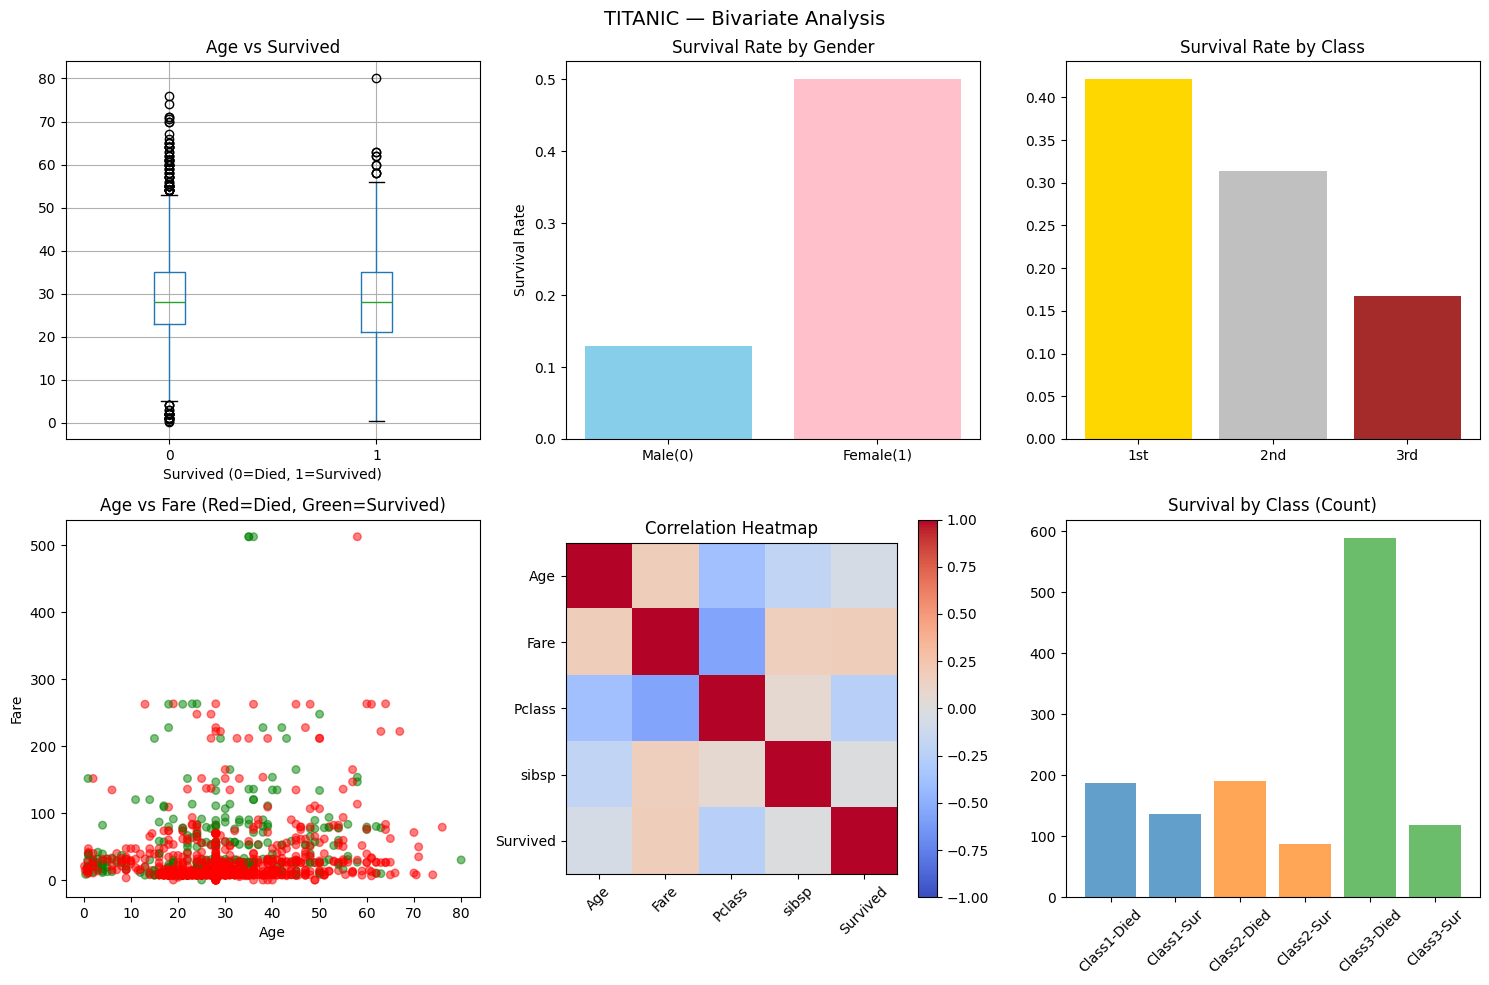

In [ ]:
# ============================================
# STEP 4 — BIVARIATE ANALYSIS
# Do columns ka ek saath analysis
# ============================================



# ---- Bivariate Plots ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Box Plot — Age by Survived
df.boxplot(column='Age', by='Survived',ax=axes[0,0] )
axes[0,0].set_title('Age vs Survived')
axes[0,0].set_xlabel('Survived (0=Died, 1=Survived)')

# Bar — Survival by Gender
survival_gender = df.groupby('Sex')['Survived'].mean()
axes[0,1].bar(['Male(0)', 'Female(1)'], survival_gender.values,
               color=['skyblue', 'pink'])
axes[0,1].set_title('Survival Rate by Gender')
axes[0,1].set_ylabel('Survival Rate')

# Bar — Survival by Class
survival_class = df.groupby('Pclass')['Survived'].mean()
axes[0,2].bar(['1st', '2nd', '3rd'], survival_class.values,
               color=['gold', 'silver', 'brown'])
axes[0,2].set_title('Survival Rate by Class')

# Scatter — Age vs Fare colored by Survived
colors = ['red' if s == 0 else 'green' for s in df['Survived']]
axes[1,0].scatter(df['Age'], df['Fare'], c=colors, alpha=0.5, s=30)
axes[1,0].set_title('Age vs Fare (Red=Died, Green=Survived)')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Fare')

# Heatmap — Correlation
corr = df[['Age','Fare','Pclass','sibsp','Survived']].corr()
im = axes[1,1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(corr.columns)))
axes[1,1].set_yticks(range(len(corr.columns)))
axes[1,1].set_xticklabels(corr.columns, rotation=45)
axes[1,1].set_yticklabels(corr.columns)
plt.colorbar(im, ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

# Count plot — Pclass by Survived
for pclass in [1, 2, 3]:
    data = df[df['Pclass'] == pclass]['Survived'].value_counts()
    axes[1,2].bar([f'Class{pclass}-Died', f'Class{pclass}-Sur'],
                   [data.get(0,0), data.get(1,0)], alpha=0.7)
axes[1,2].set_title('Survival by Class (Count)')
axes[1,2].tick_params(axis='x', rotation=45)

plt.suptitle('TITANIC — Bivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Standardization + Normalization

=== FEATURE SCALING ===

Original Data Statistics:
           Age     Fare   Pclass
count  1309.00  1309.00  1309.00
mean     29.50    33.28     2.29
std      12.91    51.74     0.84
min       0.17     0.00     1.00
25%      22.00     7.90     2.00
50%      28.00    14.45     3.00
75%      35.00    31.28     3.00
max      80.00   512.33     3.00

After StandardScaler (mean=0, sd=1):
           Age     Fare   Pclass
count  1309.00  1309.00  1309.00
mean      0.00    -0.00    -0.00
std       1.00     1.00     1.00
min      -2.27    -0.64    -1.55
25%      -0.58    -0.49    -0.35
50%      -0.12    -0.36     0.84
75%       0.43    -0.04     0.84
max       3.91     9.26     0.84

After MinMaxScaler (0 to 1):
           Age     Fare   Pclass
count  1309.00  1309.00  1309.00
mean      0.37     0.06     0.65
std       0.16     0.10     0.42
min       0.00     0.00     0.00
25%       0.27     0.02     0.50
50%       0.35     0.03     1.00
75%       0.44     0.06     1.00
max       1.00     1.00

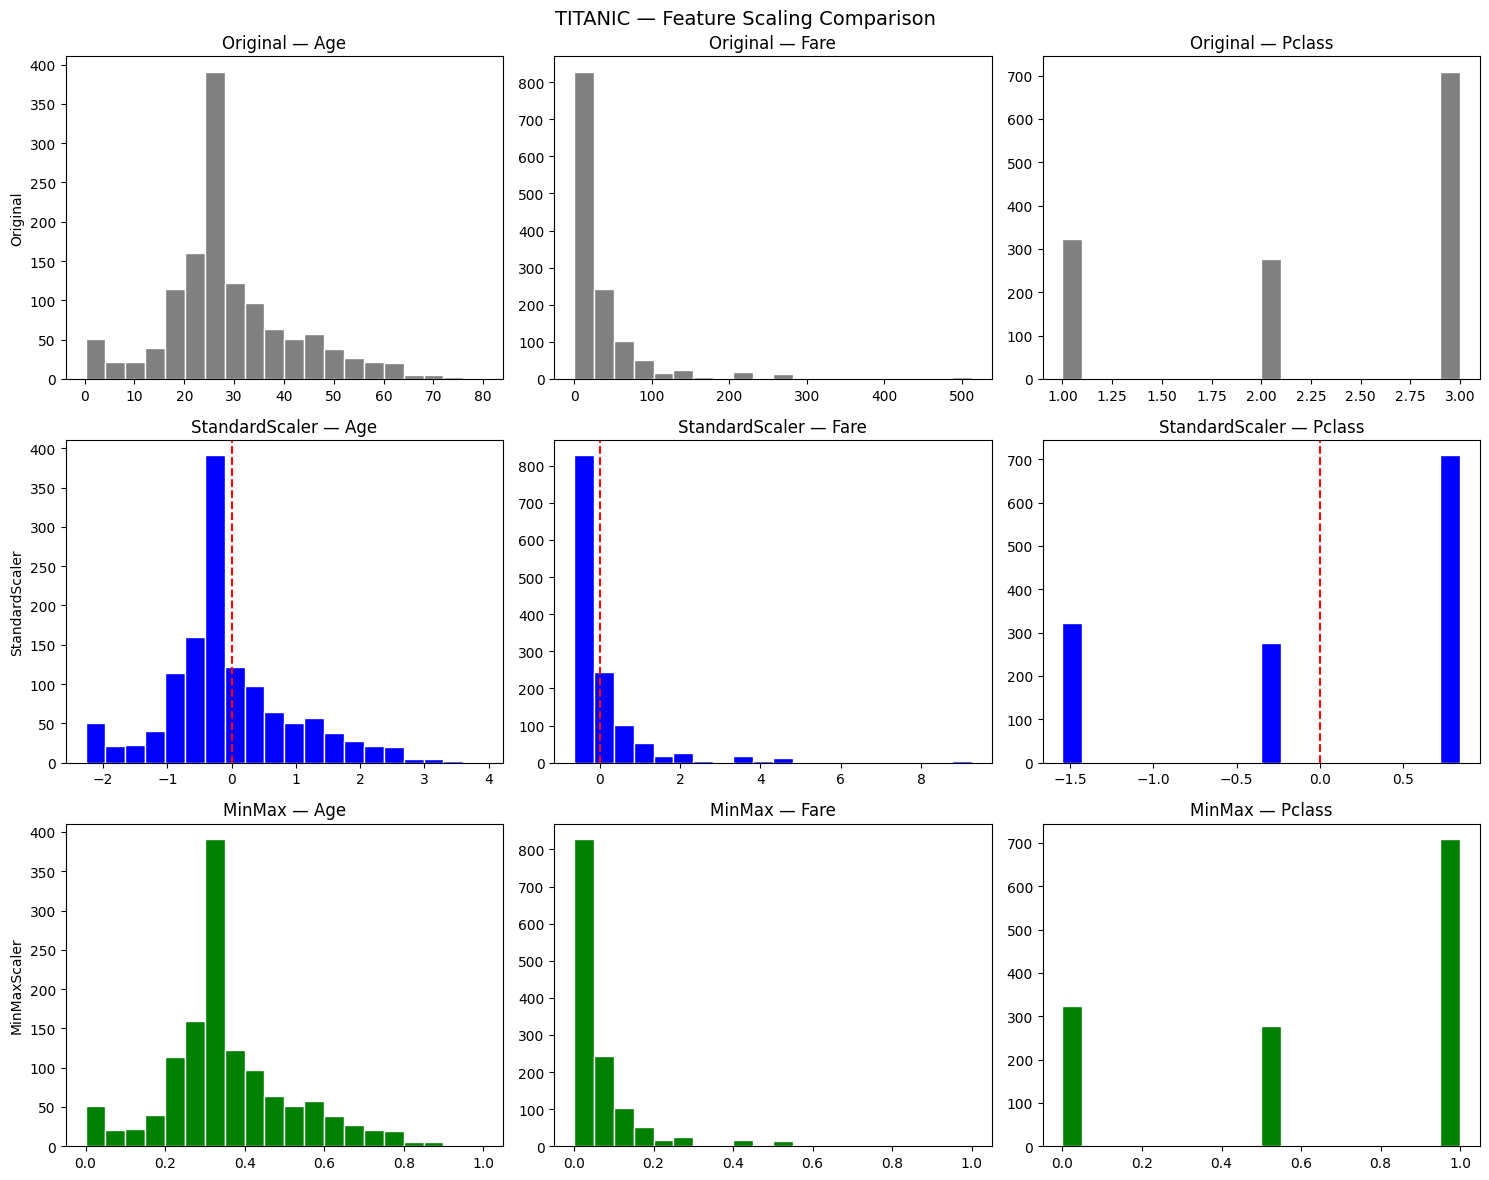

Rule: Test data pe sirf transform() karo, fit_transform() nahi!


In [42]:
# ============================================
# STEP 5 — FEATURE SCALING
# Standardization + Normalization
# ============================================

print("=== FEATURE SCALING ===")
print()

# Numerical columns select karo
num_cols = ['Age', 'Fare', 'Pclass']
X = df[num_cols].copy()

print("Original Data Statistics:")
print(X.describe().round(2))
print()

# ---- 1. Standardization (StandardScaler) ----
std_scaler = StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X), columns=num_cols)
print("After StandardScaler (mean=0, sd=1):")
print(X_std.describe().round(2))
print()

# ---- 2. Min-Max Normalization ----
mm_scaler = MinMaxScaler()
X_mm = pd.DataFrame(mm_scaler.fit_transform(X), columns=num_cols)
print("After MinMaxScaler (0 to 1):")
print(X_mm.describe().round(2))
print()

# ---- 3. Robust Scaling ----
rb_scaler = RobustScaler()
X_rb = pd.DataFrame(rb_scaler.fit_transform(X), columns=num_cols)
print("After RobustScaler (outlier resistant):")
print(X_rb.describe().round(2))
print()

# ---- Visualization ----
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(num_cols):
    # Original
    axes[0,i].hist(X[col], bins=20, color='gray', edgecolor='white')
    axes[0,i].set_title(f'Original — {col}')

    # StandardScaler
    axes[1,i].hist(X_std[col], bins=20, color='blue', edgecolor='white')
    axes[1,i].set_title(f'StandardScaler — {col}')
    axes[1,i].axvline(x=0, color='red', linestyle='--', label='mean=0')

    # MinMax
    axes[2,i].hist(X_mm[col], bins=20, color='green', edgecolor='white')
    axes[2,i].set_title(f'MinMax — {col}')

axes[0,0].set_ylabel('Original')
axes[1,0].set_ylabel('StandardScaler')
axes[2,0].set_ylabel('MinMaxScaler')

plt.suptitle('TITANIC — Feature Scaling Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print("Rule: Test data pe sirf transform() karo, fit_transform() nahi!")